# Proiect AAD - Checkpoint 1: Analiza relatiei dintre cafeina, energie, somn si puls

## Componenta echipei
- Ionescu Corina Ana
- Lazar Alessia-Alessandra
- Roibu Radu Gheorghe 343C3

## Context, motivatie, obiective si ipoteza
- Context: folosim date reale NHANES pentru a analiza relatia dintre consumul de cafeina, aportul energetic, somn, puls si date demografice.
- Motivatie: cafeina este consumata frecvent, iar efectele ei asupra odihnei si parametrilor fiziologici sunt relevante in viata de zi cu zi.
- Obiectiv: in aceasta prima etapa construim un dataset unit, curat si usor de interpretat, apoi realizam analiza exploratorie a datelor.
- Ipoteza: un consum mai mare de cafeina se poate asocia cu puls mai ridicat si cu mai putine ore de somn.
- Impact: proiectul poate evidentia tipare utile, dar nu demonstreaza cauzalitate.

## Etapa 1: Alegere date si setup

In aceasta etapa definim tema proiectului, alegem datele relevante si pregatim mediul de lucru pentru analiza. Folosim doar fisierele NHANES la nivel de participant, astfel incat toate observatiile sa poata fi unite prin `SEQN`.

### Date folosite

- `caffeine_energy.csv`
- `pulse_bp.csv`
- `sleep.csv`
- `demographics.csv`

### Obiectiv pentru aceasta etapa

Construim un set de date curat si usor de interpretat pentru a studia relatia dintre consumul de cafeina, aportul energetic, somn si puls in randul adultilor.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

caffeine_palette = {
    "Low": "#8ecae6",
    "Moderate": "#219ebc",
    "High": "#fb8500",
    "Very High": "#d62828",
}
gender_palette = {
    "Female": "#e76f51",
    "Male": "#457b9d",
    "Unknown": "#94d2bd",
}
radar_palette = {
    "Low": "#457b9d",
    "Moderate": "#2a9d8f",
    "High": "#e76f51",
}

### 1.1 Incarcarea si intelegerea datelor

Incarcam cele 4 fisiere principale si verificam rapid structura lor. Afisam un sumar compact, nu tabele brute foarte late, pentru ca scopul aici este sa intelegem clar ce date avem la dispozitie si ce coloane merita pastrate.

In [2]:
data_dir = Path(".")

main_file_map = {
    "caffeine_energy": "caffeine_energy.csv",
    "pulse_bp": "pulse_bp.csv",
    "sleep": "sleep.csv",
    "demographics": "demographics.csv",
}

missing_files = [csv_name for csv_name in main_file_map.values() if not (data_dir / csv_name).exists()]
if missing_files:
    raise FileNotFoundError("Lipsesc fisierele CSV: " + ", ".join(missing_files))

datasets = {}

for dataset_name, csv_name in main_file_map.items():
    csv_path = data_dir / csv_name
    df = pd.read_csv(csv_path)
    datasets[dataset_name] = df
    print(f"[OK] {csv_path.name} a fost incarcat. Shape: {df.shape}")

caffeine_energy_df = datasets["caffeine_energy"]
pulse_bp_df = datasets["pulse_bp"]
sleep_df = datasets["sleep"]
demographics_df = datasets["demographics"]


[OK] caffeine_energy.csv a fost incarcat. Shape: (8704, 168)
[OK] pulse_bp.csv a fost incarcat. Shape: (8704, 21)
[OK] sleep.csv a fost incarcat. Shape: (6161, 11)
[OK] demographics.csv a fost incarcat. Shape: (9254, 46)


In [3]:
raw_summary = pd.DataFrame({
    "dataset": list(datasets.keys()),
    "rows": [df.shape[0] for df in datasets.values()],
    "columns": [df.shape[1] for df in datasets.values()],
    "exemplu_coloane_brute": [
        ", ".join(df.columns[:6]) + (" ..." if df.shape[1] > 6 else "")
        for df in datasets.values()
    ],
})

display(raw_summary)


,dataset,rows,columns,exemplu_coloane_brute
0,caffeine_energy,8704,168,"SEQN, WTDRD1, WTDR2D, DR1DRSTZ, DR1EXMER, DRAB..."
1,pulse_bp,8704,21,"SEQN, PEASCCT1, BPXCHR, BPAARM, BPACSZ, BPXPLS..."
2,sleep,6161,11,"SEQN, SLQ300, SLQ310, SLD012, SLQ320, SLQ330 ..."
3,demographics,9254,46,"SEQN, SDDSRVYR, RIDSTATR, RIAGENDR, RIDAGEYR, ..."


#### Selectarea coloanelor relevante si redenumirea lor

Fisierele brute au multe coloane tehnice. In proiect pastram doar ce ne trebuie pentru analiza si facem un rename clar, usor de urmarit.


In [4]:
def select_and_rename_columns(df, rename_map, dataset_name, required_columns=None):
    if required_columns is None:
        required_columns = list(rename_map.keys())

    missing_required = [col for col in required_columns if col not in df.columns]
    if missing_required:
        raise KeyError(f"In tabelul {dataset_name} lipsesc coloanele: {missing_required}")

    selected_df = df[list(rename_map.keys())].copy()
    selected_df = selected_df.rename(columns=rename_map)
    return selected_df


nutrition_rename_map = {
    "SEQN": "SEQN",
    "DR1TKCAL": "energy_kcal",
    "DR1TCAFF": "caffeine_mg",
}

bp_rename_map = {
    "SEQN": "SEQN",
    "BPXPLS": "pulse",
    "BPXSY1": "systolic_1",
    "BPXDI1": "diastolic_1",
    "BPXSY2": "systolic_2",
    "BPXDI2": "diastolic_2",
    "BPXSY3": "systolic_3",
    "BPXDI3": "diastolic_3",
    "BPXSY4": "systolic_4",
    "BPXDI4": "diastolic_4",
}

sleep_rename_map = {
    "SEQN": "SEQN",
    "SLD012": "sleep_weekday_hours",
    "SLD013": "sleep_weekend_hours",
}

demographics_rename_map = {
    "SEQN": "SEQN",
    "RIDAGEYR": "age",
    "RIAGENDR": "gender_code",
}

nutrition_selected = select_and_rename_columns(caffeine_energy_df, nutrition_rename_map, "caffeine_energy.csv")
bp_selected = select_and_rename_columns(pulse_bp_df, bp_rename_map, "pulse_bp.csv", required_columns=["SEQN", "BPXPLS"])
sleep_selected = select_and_rename_columns(sleep_df, sleep_rename_map, "sleep.csv")
demographics_selected = select_and_rename_columns(demographics_df, demographics_rename_map, "demographics.csv")

demographics_selected["gender"] = demographics_selected["gender_code"].map({1: "Male", 2: "Female"})


In [5]:
data_dictionary = pd.DataFrame([
    {"fisier": "caffeine_energy.csv", "coloana_initiala": "DR1TKCAL", "coloana_finala": "energy_kcal", "explicatie": "aport energetic total pe zi"},
    {"fisier": "caffeine_energy.csv", "coloana_initiala": "DR1TCAFF", "coloana_finala": "caffeine_mg", "explicatie": "cantitatea totala de cafeina"},
    {"fisier": "pulse_bp.csv", "coloana_initiala": "BPXPLS", "coloana_finala": "pulse", "explicatie": "puls"},
    {"fisier": "pulse_bp.csv", "coloana_initiala": "BPXSY1 ... BPXSY4", "coloana_finala": "systolic_*", "explicatie": "masuratori de tensiune sistolica"},
    {"fisier": "pulse_bp.csv", "coloana_initiala": "BPXDI1 ... BPXDI4", "coloana_finala": "diastolic_*", "explicatie": "masuratori de tensiune diastolica"},
    {"fisier": "sleep.csv", "coloana_initiala": "SLD012", "coloana_finala": "sleep_weekday_hours", "explicatie": "ore de somn in timpul saptamanii"},
    {"fisier": "sleep.csv", "coloana_initiala": "SLD013", "coloana_finala": "sleep_weekend_hours", "explicatie": "ore de somn in weekend"},
    {"fisier": "demographics.csv", "coloana_initiala": "RIDAGEYR", "coloana_finala": "age", "explicatie": "varsta"},
    {"fisier": "demographics.csv", "coloana_initiala": "RIAGENDR", "coloana_finala": "gender", "explicatie": "gen"},
])

display(data_dictionary)


,fisier,coloana_initiala,coloana_finala,explicatie
0,caffeine_energy.csv,DR1TKCAL,energy_kcal,aport energetic total pe zi
1,caffeine_energy.csv,DR1TCAFF,caffeine_mg,cantitatea totala de cafeina
2,pulse_bp.csv,BPXPLS,pulse,puls
3,pulse_bp.csv,BPXSY1 ... BPXSY4,systolic_*,masuratori de tensiune sistolica
4,pulse_bp.csv,BPXDI1 ... BPXDI4,diastolic_*,masuratori de tensiune diastolica
5,sleep.csv,SLD012,sleep_weekday_hours,ore de somn in timpul saptamanii
6,sleep.csv,SLD013,sleep_weekend_hours,ore de somn in weekend
7,demographics.csv,RIDAGEYR,age,varsta
8,demographics.csv,RIAGENDR,gender,gen


In [6]:
readable_previews = {
    "Nutritie - cafeina si energie": nutrition_selected,
    "Semne vitale - puls si tensiune": bp_selected,
    "Somn": sleep_selected,
    "Demografie": demographics_selected[["SEQN", "age", "gender_code", "gender"]],
}

for table_name, df in readable_previews.items():
    print("=" * 90)
    print(table_name)
    display(df.head())


Nutritie - cafeina si energie


,SEQN,energy_kcal,caffeine_mg
0,93703,NaN,NaN
1,93704,"1,230.00",8.00
2,93705,"1,202.00",361.00
3,93706,"1,987.00",0.00
4,93707,"1,775.00",21.00


Semne vitale - puls si tensiune


,SEQN,pulse,systolic_1,diastolic_1,systolic_2,diastolic_2,systolic_3,diastolic_3,systolic_4,diastolic_4
0,93703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705,52.00,NaN,NaN,NaN,NaN,202.00,62.00,198.00,74.00
3,93706,82.00,112.00,74.00,114.00,70.00,108.00,76.00,NaN,NaN
4,93707,100.00,128.00,38.00,128.00,46.00,128.00,58.00,NaN,NaN


Somn


,SEQN,sleep_weekday_hours,sleep_weekend_hours
0,93705,8.00,8.00
1,93706,10.50,11.50
2,93708,8.00,8.00
3,93709,7.00,6.50
4,93711,7.00,9.00


Demografie


,SEQN,age,gender_code,gender
0,93703,2,2,Female
1,93704,2,1,Male
2,93705,66,2,Female
3,93706,18,1,Male
4,93707,13,1,Male


## Etapa 2: Corectare si analiza date

In aceasta etapa corectam problemele de calitate a datelor: duplicate, valori lipsa, valori suspecte si denumiri greu de inteles. Apoi unim tabelele si construim variabilele derivate necesare pentru analiza.

In [7]:
def prepare_common_columns(df):
    df = df.copy()
    initial_rows = len(df)
    duplicate_count = int(df.duplicated().sum())
    df = df.drop_duplicates()
    df = df.dropna(subset=["SEQN"])
    df["SEQN"] = pd.to_numeric(df["SEQN"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["SEQN"])
    return df, initial_rows, duplicate_count


def convert_numeric_columns(df, columns):
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def invalid_to_nan(df, column, min_value=None, max_value=None):
    df = df.copy()
    if column not in df.columns:
        return df

    valid_mask = pd.Series(True, index=df.index)

    if min_value is not None:
        valid_mask &= df[column].isna() | (df[column] >= min_value)
    if max_value is not None:
        valid_mask &= df[column].isna() | (df[column] <= max_value)

    df.loc[~valid_mask, column] = np.nan
    return df


def missing_report(df, table_name):
    return pd.DataFrame({
        "table": table_name,
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }).sort_values(by="missing_pct", ascending=False)


In [8]:
nutrition_clean, nutrition_initial_rows, nutrition_duplicates = prepare_common_columns(nutrition_selected)
bp_clean, bp_initial_rows, bp_duplicates = prepare_common_columns(bp_selected)
sleep_clean, sleep_initial_rows, sleep_duplicates = prepare_common_columns(sleep_selected)
demographics_clean, demo_initial_rows, demo_duplicates = prepare_common_columns(demographics_selected)

nutrition_clean = convert_numeric_columns(nutrition_clean, ["energy_kcal", "caffeine_mg"])
bp_clean = convert_numeric_columns(
    bp_clean,
    ["pulse", "systolic_1", "diastolic_1", "systolic_2", "diastolic_2", "systolic_3", "diastolic_3", "systolic_4", "diastolic_4"]
)
sleep_clean = convert_numeric_columns(sleep_clean, ["sleep_weekday_hours", "sleep_weekend_hours"])
demographics_clean = convert_numeric_columns(demographics_clean, ["age", "gender_code"])

suspect_energy_nonpositive_count = int(nutrition_clean["energy_kcal"].le(0).fillna(False).sum())
nutrition_clean.loc[nutrition_clean["energy_kcal"] <= 0, "energy_kcal"] = np.nan

nutrition_clean = invalid_to_nan(nutrition_clean, "energy_kcal", 0, 10000)
nutrition_clean = invalid_to_nan(nutrition_clean, "caffeine_mg", 0, 1500)

bp_clean = invalid_to_nan(bp_clean, "pulse", 30, 220)
for column in ["systolic_1", "systolic_2", "systolic_3", "systolic_4"]:
    bp_clean = invalid_to_nan(bp_clean, column, 70, 260)
for column in ["diastolic_1", "diastolic_2", "diastolic_3", "diastolic_4"]:
    bp_clean = invalid_to_nan(bp_clean, column, 30, 160)

sleep_clean = invalid_to_nan(sleep_clean, "sleep_weekday_hours", 0, 24)
sleep_clean = invalid_to_nan(sleep_clean, "sleep_weekend_hours", 0, 24)
demographics_clean = invalid_to_nan(demographics_clean, "age", 0, 120)

demographics_clean["gender"] = demographics_clean["gender"].fillna("Unknown")

cleaning_summary = pd.DataFrame([
    {"table": "nutrition", "rows_initial": nutrition_initial_rows, "duplicates_removed": nutrition_duplicates, "rows_after_cleaning": len(nutrition_clean)},
    {"table": "bp", "rows_initial": bp_initial_rows, "duplicates_removed": bp_duplicates, "rows_after_cleaning": len(bp_clean)},
    {"table": "sleep", "rows_initial": sleep_initial_rows, "duplicates_removed": sleep_duplicates, "rows_after_cleaning": len(sleep_clean)},
    {"table": "demographics", "rows_initial": demo_initial_rows, "duplicates_removed": demo_duplicates, "rows_after_cleaning": len(demographics_clean)},
])

quality_flags_summary = pd.DataFrame([
    {"indicator": "valori_energy_kcal_<=_0_tratate_ca_lipsa", "count": suspect_energy_nonpositive_count},
    {"indicator": "randuri_nutritie_cu_energy_kcal_lipsa_dupa_curatare", "count": int(nutrition_clean["energy_kcal"].isna().sum())},
])

display(cleaning_summary)
display(quality_flags_summary)


,table,rows_initial,duplicates_removed,rows_after_cleaning
0,nutrition,8704,0,8704
1,bp,8704,0,8704
2,sleep,6161,0,6161
3,demographics,9254,0,9254


,indicator,count
0,valori_energy_kcal_<=_0_tratate_ca_lipsa,1
1,randuri_nutritie_cu_energy_kcal_lipsa_dupa_cur...,1224


In [9]:
missing_reports = pd.concat([
    missing_report(nutrition_clean, "nutrition"),
    missing_report(bp_clean, "bp"),
    missing_report(sleep_clean, "sleep"),
    missing_report(demographics_clean, "demographics"),
], ignore_index=True)

for table_name in ["nutrition", "bp", "sleep", "demographics"]:
    print("=" * 90)
    print(f"Missing values pentru {table_name}")
    display(missing_reports[missing_reports["table"] == table_name].reset_index(drop=True))


Missing values pentru nutrition


,table,column,missing_count,missing_pct
0,nutrition,caffeine_mg,1232,14.15
1,nutrition,energy_kcal,1224,14.06
2,nutrition,SEQN,0,0.00


Missing values pentru bp


,table,column,missing_count,missing_pct
0,bp,diastolic_4,8160,93.75
1,bp,systolic_4,8148,93.61
2,bp,diastolic_1,2548,29.27
3,bp,systolic_1,2402,27.60
4,bp,diastolic_3,2307,26.51
5,bp,diastolic_2,2280,26.19
6,bp,systolic_3,2166,24.89
7,bp,systolic_2,2141,24.60
8,bp,pulse,1962,22.54
9,bp,SEQN,0,0.00


Missing values pentru sleep


,table,column,missing_count,missing_pct
0,sleep,sleep_weekend_hours,57,0.93
1,sleep,sleep_weekday_hours,48,0.78
2,sleep,SEQN,0,0.00


Missing values pentru demographics


,table,column,missing_count,missing_pct
0,demographics,SEQN,0,0.00
1,demographics,age,0,0.00
2,demographics,gender_code,0,0.00
3,demographics,gender,0,0.00


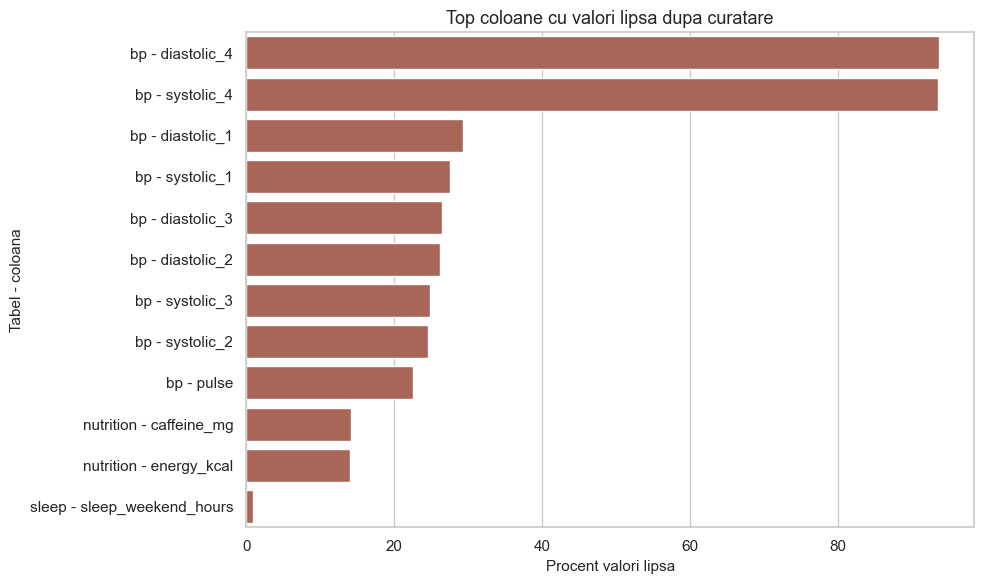

In [10]:
missing_plot_df = (
    missing_reports.loc[missing_reports["missing_pct"] > 0, ["table", "column", "missing_pct"]]
    .copy()
)
missing_plot_df["label"] = missing_plot_df["table"] + " - " + missing_plot_df["column"]
missing_plot_df = missing_plot_df.sort_values("missing_pct", ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=missing_plot_df, x="missing_pct", y="label", color="#b55d4c")
plt.title("Top coloane cu valori lipsa dupa curatare")
plt.xlabel("Procent valori lipsa")
plt.ylabel("Tabel - coloana")
plt.tight_layout()
plt.show()


Graficul de mai sus arata unde se concentreaza cel mai mult lipsurile din date. Lipsa nu este tratata agresiv: variabilele obligatorii pentru analiza principala sunt filtrate, dar pentru somn pastram observatiile partiale si folosim ulterior o agregare ponderata pe zilele disponibile.


### 2.1 Unirea tabelelor si analiza descriptiva

Dupa curatare, unim cele patru surse prin `SEQN` si obtinem setul final de analiza. In continuare verificam tipurile de date, statisticile descriptive si numarul de participanti pastrati in lotul final.

In [11]:
merged_df = (
    nutrition_clean
    .merge(bp_clean, on="SEQN", how="inner")
    .merge(sleep_clean, on="SEQN", how="inner")
    .merge(demographics_clean, on="SEQN", how="inner")
)

analysis_df = merged_df.copy()
analysis_df = analysis_df.drop_duplicates()
analysis_df = analysis_df[analysis_df["age"] >= 18].copy()
analysis_df = analysis_df.dropna(subset=["caffeine_mg", "energy_kcal", "pulse", "age"]).copy()

join_summary = pd.DataFrame([
    {"stage": "merged_inner", "rows": len(merged_df), "participants": merged_df["SEQN"].nunique()},
    {"stage": "analysis_18plus", "rows": len(analysis_df), "participants": analysis_df["SEQN"].nunique()},
])

display(join_summary)


,stage,rows,participants
0,merged_inner,5828,5828
1,analysis_18plus,4824,4824


In [12]:
print("Tipuri de date in analysis_df:")
display(analysis_df.dtypes.to_frame("dtype"))

print("Statistici descriptive:")
display(analysis_df.describe(include="all").T)


Tipuri de date in analysis_df:


,dtype
SEQN,Int64
energy_kcal,float64
caffeine_mg,float64
pulse,float64
systolic_1,float64
diastolic_1,float64
systolic_2,float64
diastolic_2,float64
systolic_3,float64
diastolic_3,float64


Statistici descriptive:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SEQN,"4,824.00",<NA>,<NA>,<NA>,"98,286.99","2,682.07","93,705.00","95,952.75","98,299.50","100,582.25","102,956.00"
energy_kcal,"4,824.00",NaN,NaN,NaN,"2,103.09","1,002.61",3.00,"1,408.00","1,941.00","2,615.25","8,538.00"
caffeine_mg,"4,824.00",NaN,NaN,NaN,135.55,161.48,0.00,9.75,94.00,193.00,"1,211.00"
pulse,"4,824.00",NaN,NaN,NaN,71.72,11.58,42.00,64.00,70.00,78.00,136.00
systolic_1,"4,489.00",NaN,NaN,NaN,125.80,19.33,86.00,112.00,124.00,136.00,224.00
diastolic_1,"4,456.00",NaN,NaN,NaN,72.30,11.93,30.00,64.00,72.00,80.00,124.00
systolic_2,"4,701.00",NaN,NaN,NaN,126.14,19.92,80.00,112.00,124.00,136.00,236.00
diastolic_2,"4,678.00",NaN,NaN,NaN,72.60,11.97,30.00,64.00,72.00,80.00,126.00
systolic_3,"4,689.00",NaN,NaN,NaN,125.68,19.74,80.00,112.00,122.00,136.00,238.00
diastolic_3,"4,668.00",NaN,NaN,NaN,72.55,12.02,30.00,64.00,72.00,80.00,126.00


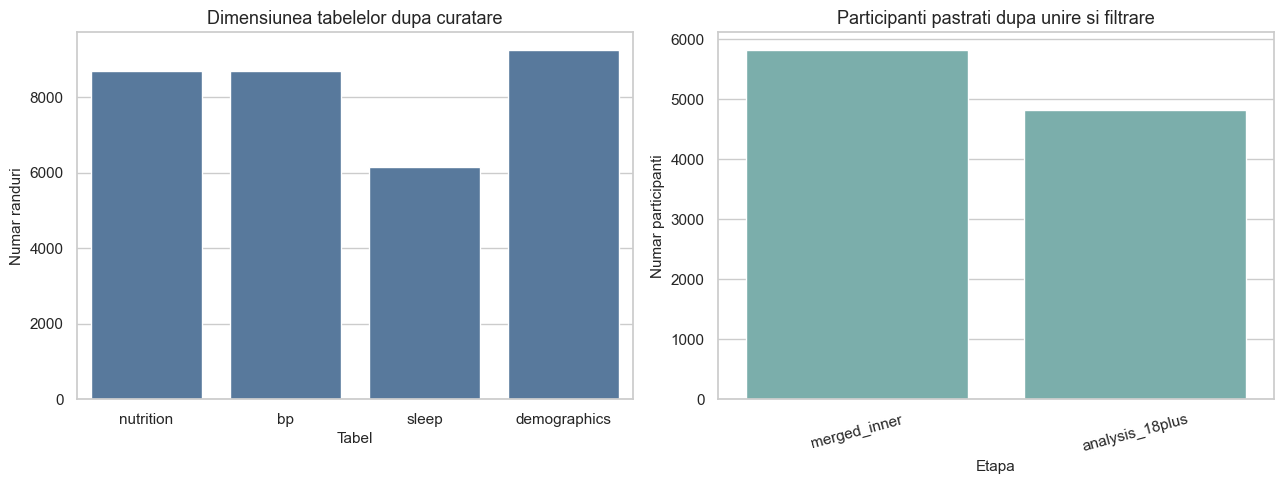

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=cleaning_summary, x="table", y="rows_after_cleaning", ax=axes[0], color="#4c78a8")
axes[0].set_title("Dimensiunea tabelelor dupa curatare")
axes[0].set_xlabel("Tabel")
axes[0].set_ylabel("Numar randuri")

sns.barplot(data=join_summary, x="stage", y="participants", ax=axes[1], color="#72b7b2")
axes[1].set_title("Participanti pastrati dupa unire si filtrare")
axes[1].set_xlabel("Etapa")
axes[1].set_ylabel("Numar participanti")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


Aceste grafice arata ca filtrarea nu a fost facuta arbitrar, ci gradual. Scopul a fost sa pastram un lot final coerent, nu sa maximizam artificial numarul de randuri cu pretul calitatii datelor.


#### Variabile derivate si setul final de analiza

Inainte de vizualizari si modelare, construim cateva variabile derivate care simplifica interpretarea:

- `avg_sleep_hours` = medie saptamanala ponderata, calculata ca `(5 * sleep_weekday_hours + 2 * sleep_weekend_hours) / 7`
- `avg_systolic_bp`
- `avg_diastolic_bp`
- `caffeine_group`
- `age_group`
- `high_pulse`

Aceste coloane ne ajuta sa comparam participantii mai usor si sa rezumam mai bine datele.


In [14]:
systolic_columns = [col for col in ["systolic_1", "systolic_2", "systolic_3", "systolic_4"] if col in analysis_df.columns]
diastolic_columns = [col for col in ["diastolic_1", "diastolic_2", "diastolic_3", "diastolic_4"] if col in analysis_df.columns]

analysis_df["avg_systolic_bp"] = analysis_df[systolic_columns].mean(axis=1, skipna=True)
analysis_df["avg_diastolic_bp"] = analysis_df[diastolic_columns].mean(axis=1, skipna=True)

sleep_weight_sum = (
    analysis_df["sleep_weekday_hours"].notna().astype(int) * 5
    + analysis_df["sleep_weekend_hours"].notna().astype(int) * 2
)
sleep_weighted_sum = (
    analysis_df["sleep_weekday_hours"].fillna(0) * 5
    + analysis_df["sleep_weekend_hours"].fillna(0) * 2
)
analysis_df["avg_sleep_hours"] = sleep_weighted_sum / sleep_weight_sum.replace(0, np.nan)

analysis_df["caffeine_group"] = pd.cut(
    analysis_df["caffeine_mg"],
    bins=[-0.001, 50, 150, 300, np.inf],
    labels=["Low", "Moderate", "High", "Very High"],
    right=True
)

analysis_df["age_group"] = pd.cut(
    analysis_df["age"],
    bins=[18, 30, 45, 60, np.inf],
    labels=["18-29", "30-44", "45-59", "60+"],
    right=False
)

default_high_pulse_threshold = 90
positive_count_default = int((analysis_df["pulse"] > default_high_pulse_threshold).sum())
min_positive_needed = max(30, int(0.05 * len(analysis_df)))

if positive_count_default >= min_positive_needed:
    high_pulse_threshold = default_high_pulse_threshold
else:
    high_pulse_threshold = float(analysis_df["pulse"].quantile(0.75))

analysis_df["high_pulse"] = (analysis_df["pulse"] > high_pulse_threshold).astype(int)

analysis_df["caffeine_group"] = pd.Categorical(
    analysis_df["caffeine_group"],
    categories=["Low", "Moderate", "High", "Very High"],
    ordered=True
)

analysis_df["age_group"] = pd.Categorical(
    analysis_df["age_group"],
    categories=["18-29", "30-44", "45-59", "60+"],
    ordered=True
)

print("avg_sleep_hours a fost calculat ca medie saptamanala ponderata (5 zile lucratoare + 2 zile de weekend).")
print(f"Pragul folosit pentru high_pulse: {high_pulse_threshold:.2f}")


avg_sleep_hours a fost calculat ca medie saptamanala ponderata (5 zile lucratoare + 2 zile de weekend).
Pragul folosit pentru high_pulse: 90.00


In [15]:
analysis_df.to_csv("final_merged_dataset.csv", index=False)
print("[OK] final_merged_dataset.csv a fost salvat.")

display(analysis_df[[
    "SEQN", "energy_kcal", "caffeine_mg", "pulse",
    "avg_sleep_hours", "avg_systolic_bp", "avg_diastolic_bp",
    "age", "gender", "caffeine_group", "age_group", "high_pulse"
]].head())


[OK] final_merged_dataset.csv a fost salvat.


,SEQN,energy_kcal,caffeine_mg,pulse,avg_sleep_hours,avg_systolic_bp,avg_diastolic_bp,age,gender,caffeine_group,age_group,high_pulse
0,93705,"1,202.00",361.00,52.00,8.00,200.00,68.00,66.00,Female,Very High,60+,0
1,93706,"1,987.00",0.00,82.00,10.79,111.33,73.33,18.00,Male,Low,18-29,0
2,93708,"1,251.00",33.00,68.00,8.00,142.00,76.00,66.00,Female,Low,60+,0
4,93711,"2,840.00",347.00,62.00,7.57,101.33,66.67,56.00,Male,Very High,45-59,0
5,93712,"2,045.00",0.00,68.00,7.93,113.33,70.00,18.00,Male,Low,18-29,0


## Etapa 3: Grafice si interpretare

Ultima etapa din Checkpoint 1 este partea vizuala. Aici urmarim distributiile, diferentele dintre grupuri si relatiile dintre variabile, astfel incat sa intelegem ce tipare apar in date inainte de orice modelare.

In [16]:
def show_distribution_plots(df):
    columns_to_plot = [
        ("caffeine_mg", "Distributia consumului de cafeina", "Cafeina (mg)"),
        ("energy_kcal", "Distributia aportului energetic", "Energie (kcal)"),
        ("pulse", "Distributia pulsului", "Puls"),
        ("avg_sleep_hours", "Distributia somnului saptamanal ponderat", "Somn saptamanal ponderat (ore)"),
        ("age", "Distributia varstei", "Varsta (ani)"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()

    for ax, (column, title, xlabel) in zip(axes, columns_to_plot):
        sns.histplot(df[column].dropna(), bins=30, kde=True, ax=ax, color="#2a7f62")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frecventa")

    axes[-1].axis("off")
    plt.tight_layout()
    plt.show()


def ordered_barplot(data, x, y, title, xlabel, ylabel, palette="crest"):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, x=x, y=y, palette=palette)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def violin_boxplot(ax, data, x, y, title, xlabel, ylabel, palette, order=None):
    sns.violinplot(
        data=data,
        x=x,
        y=y,
        order=order,
        palette=palette,
        inner=None,
        cut=0,
        linewidth=0,
        saturation=0.85,
        ax=ax,
    )
    sns.boxplot(
        data=data,
        x=x,
        y=y,
        order=order,
        width=0.18,
        showcaps=True,
        showfliers=False,
        boxprops={"facecolor": "white", "alpha": 0.9, "zorder": 3},
        whiskerprops={"linewidth": 1.2},
        medianprops={"color": "#1f1f1f", "linewidth": 1.6},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def lollipop_plot(ax, data, category_col, value_col, title, xlabel, ylabel, color):
    y_pos = np.arange(len(data))
    ax.hlines(y=y_pos, xmin=0, xmax=data[value_col], color=color, linewidth=2, alpha=0.8)
    ax.scatter(data[value_col], y_pos, color=color, s=80, zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(data[category_col])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


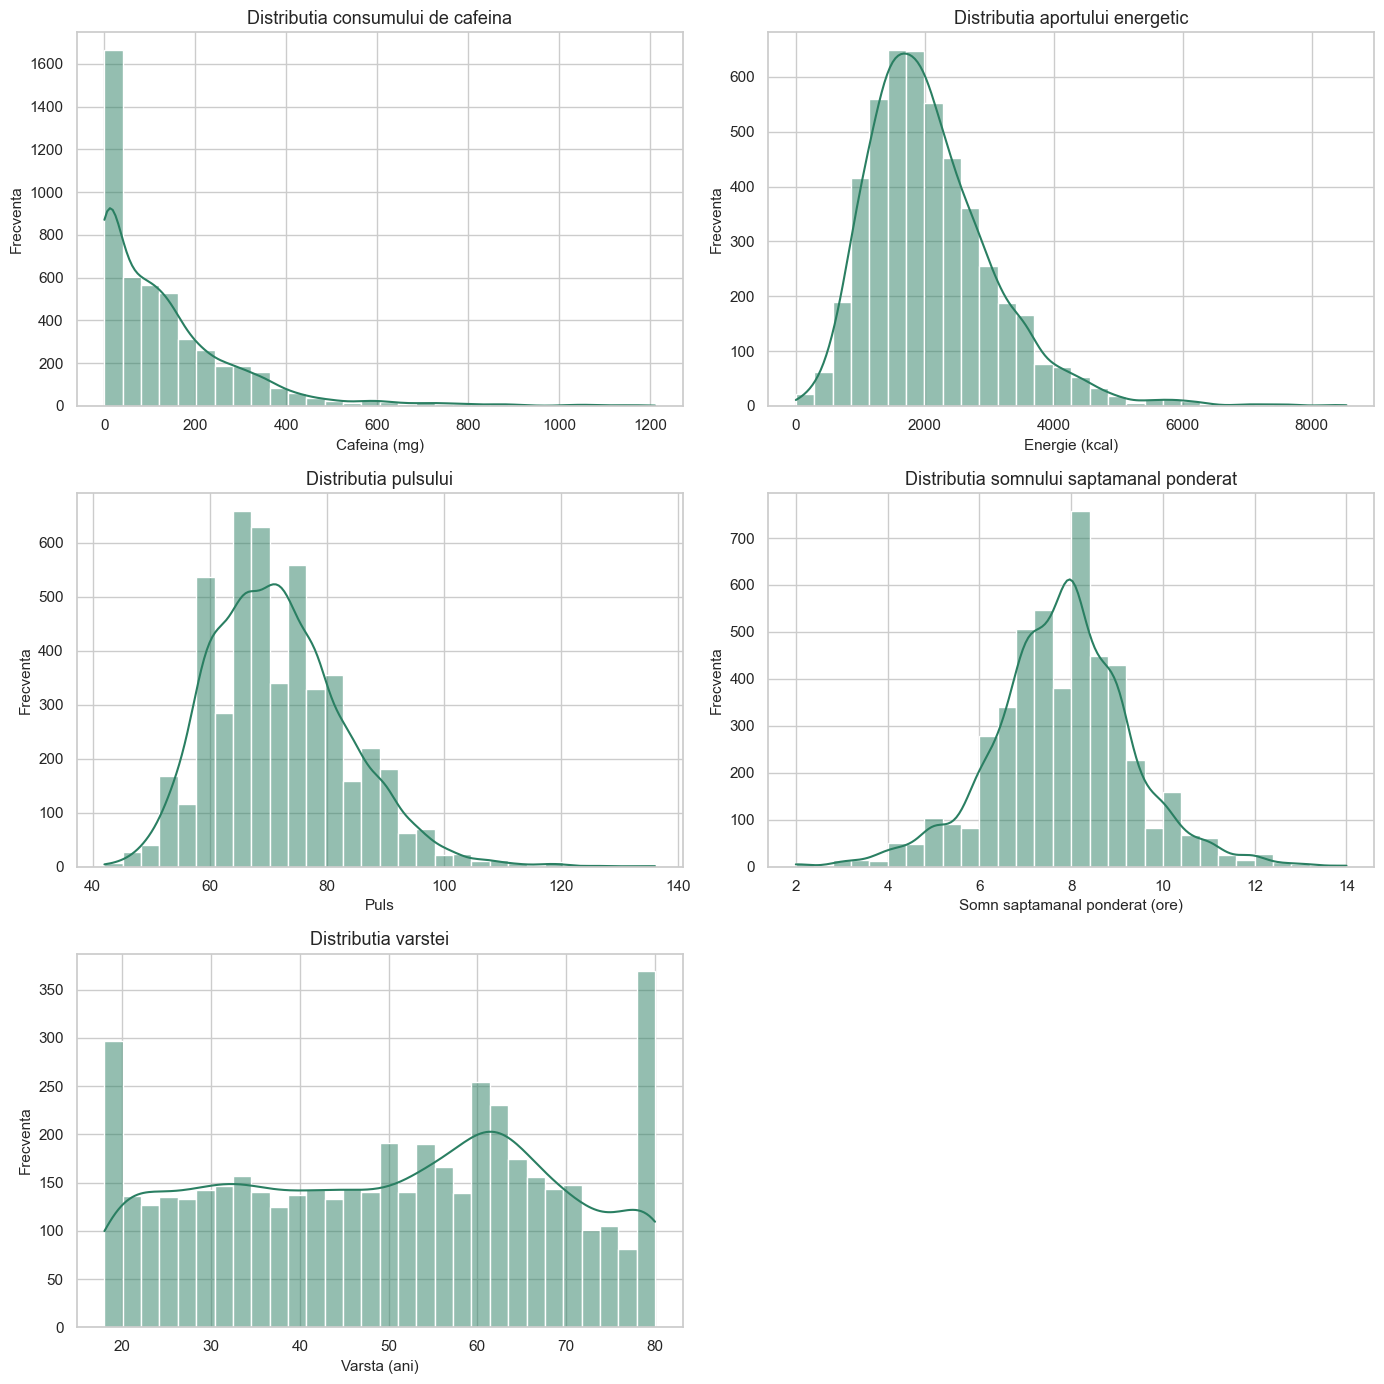

In [17]:
show_distribution_plots(analysis_df)


### Interpretare scurta dupa distributii

- Distributiile pentru `caffeine_mg` si `energy_kcal` sunt asimetrice spre dreapta, ceea ce sugereaza prezenta unor valori mari, dar relativ rare.
- `avg_sleep_hours` trebuie citita ca medie saptamanala ponderata, nu ca medie simpla intre doua tipuri de zi.
- Histogramele sugereaza ca valorile extreme merita investigate, dar nu justifica automat eliminarea lor.


#### Q1, Q3, IQR si outlieri

Pe langa grafice, calculam si quartilele Q1 si Q3, intervalul interquartilic (IQR), precum si limitele clasice pentru identificarea valorilor extreme.


### Decizia metodologica privind outlierii

Valorile imposibile au fost tratate explicit ca lipsa. In schimb, outlierii biologic plauzibili identificati prin IQR nu au fost eliminati automat. Nu am aplicat o stergere agresiva a valorilor extreme doar pentru ca sunt rare, deoarece am vrut sa pastram variabilitatea realista a datelor.


In [18]:
iqr_columns = [
    "caffeine_mg",
    "energy_kcal",
    "pulse",
    "avg_sleep_hours",
    "age",
    "avg_systolic_bp",
    "avg_diastolic_bp",
]

iqr_summary_rows = []

for column in iqr_columns:
    series = analysis_df[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()

    iqr_summary_rows.append({
        "variable": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
    })

iqr_summary = pd.DataFrame(iqr_summary_rows).round(3)
display(iqr_summary)


,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count
0,caffeine_mg,9.75,193.00,183.25,-265.12,467.88,197
1,energy_kcal,"1,408.00","2,615.25","1,207.25",-402.88,"4,426.12",133
2,pulse,64.00,78.00,14.00,43.00,99.00,90
3,avg_sleep_hours,7.00,8.71,1.71,4.43,11.29,189
4,age,34.00,64.00,30.00,-11.00,109.00,0
5,avg_systolic_bp,112.00,136.67,24.67,75.00,173.67,128
6,avg_diastolic_bp,65.33,80.00,14.67,43.33,102.00,81


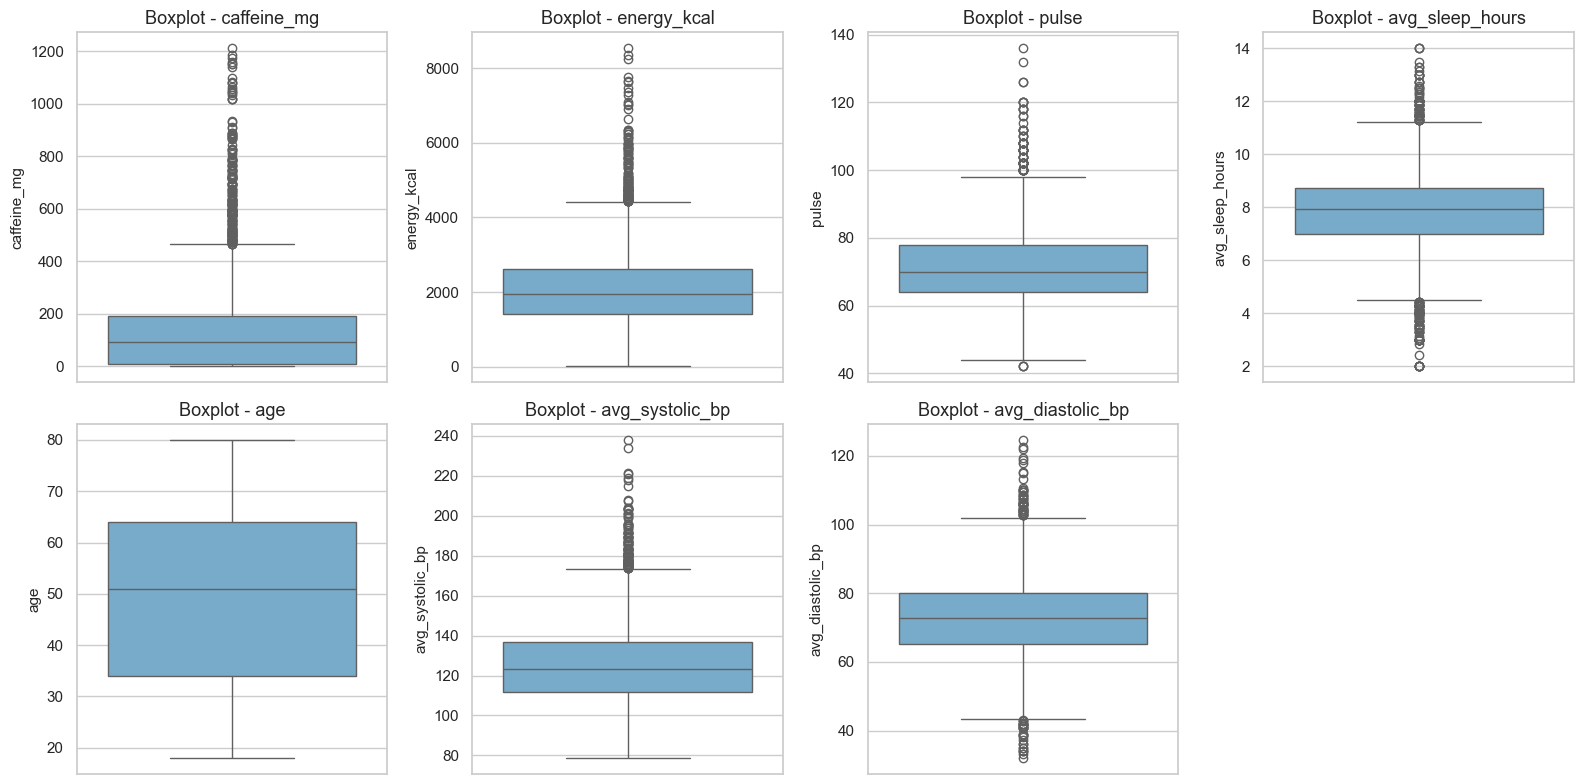

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, iqr_columns):
    sns.boxplot(y=analysis_df[column], ax=ax, color="#6baed6")
    ax.set_title(f"Boxplot - {column}")
    ax.set_xlabel("")
    ax.set_ylabel(column)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


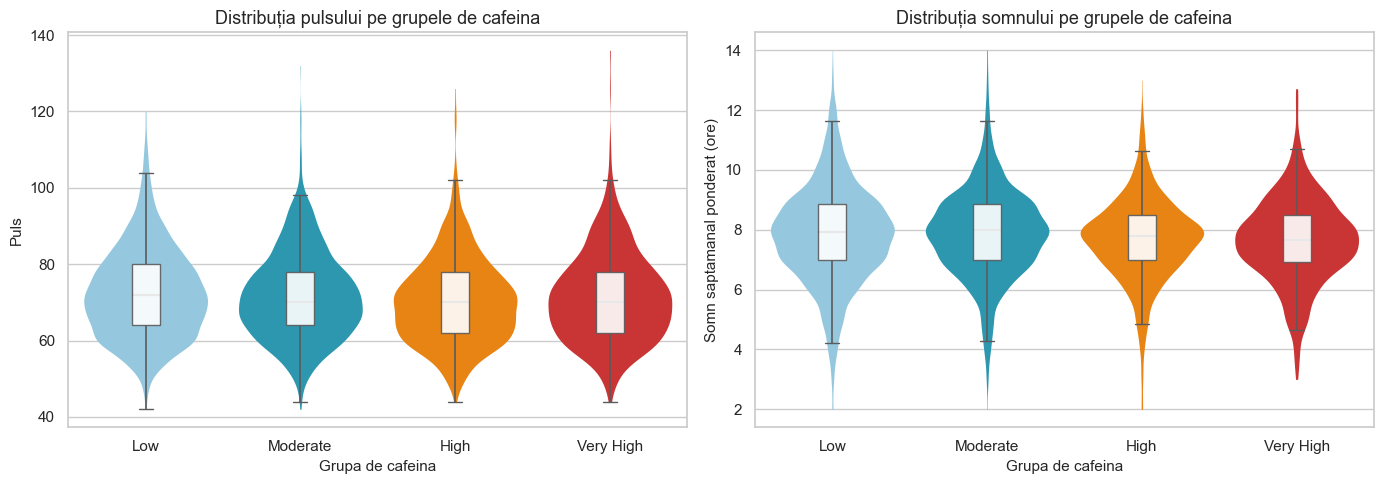

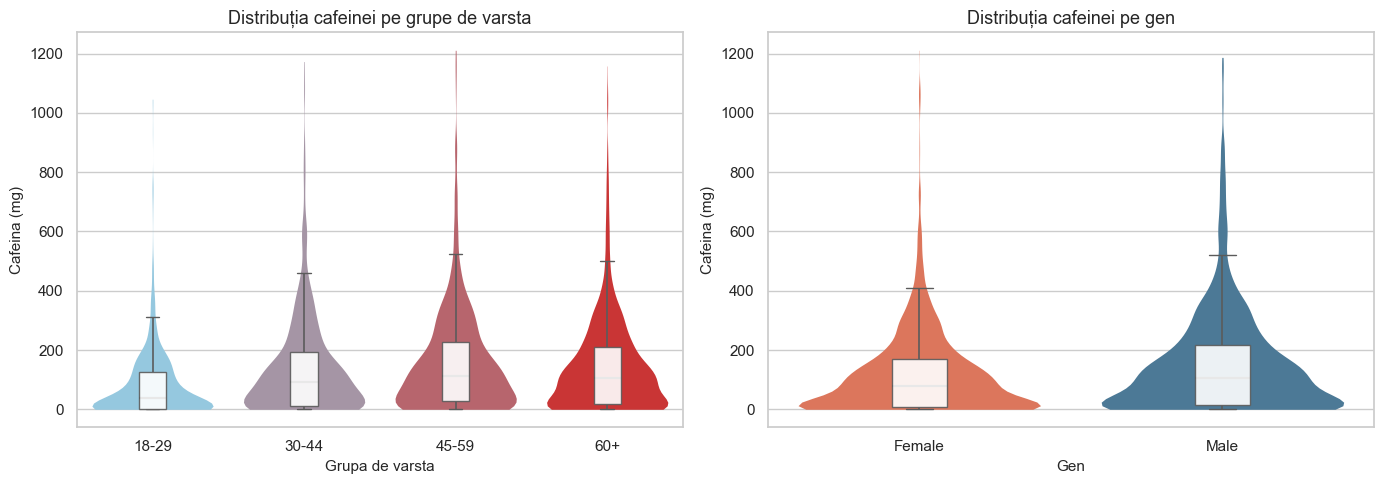

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

violin_boxplot(
    axes[0],
    analysis_df,
    x="caffeine_group",
    y="pulse",
    title="DistribuÃˆâ€ºia pulsului pe grupele de cafeina",
    xlabel="Grupa de cafeina",
    ylabel="Puls",
    palette=caffeine_palette,
    order=["Low", "Moderate", "High", "Very High"],
)

violin_boxplot(
    axes[1],
    analysis_df,
    x="caffeine_group",
    y="avg_sleep_hours",
    title="DistribuÃˆâ€ºia somnului pe grupele de cafeina",
    xlabel="Grupa de cafeina",
    ylabel="Somn saptamanal ponderat (ore)",
    palette=caffeine_palette,
    order=["Low", "Moderate", "High", "Very High"],
)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_palette = sns.color_palette("blend:#8ecae6,#d62828", n_colors=4)
gender_order = [g for g in ["Female", "Male", "Unknown"] if g in analysis_df["gender"].dropna().unique()]

violin_boxplot(
    axes[0],
    analysis_df,
    x="age_group",
    y="caffeine_mg",
    title="DistribuÃˆâ€ºia cafeinei pe grupe de varsta",
    xlabel="Grupa de varsta",
    ylabel="Cafeina (mg)",
    palette=age_palette,
    order=["18-29", "30-44", "45-59", "60+"],
)

violin_boxplot(
    axes[1],
    analysis_df,
    x="gender",
    y="caffeine_mg",
    title="DistribuÃˆâ€ºia cafeinei pe gen",
    xlabel="Gen",
    ylabel="Cafeina (mg)",
    palette=gender_palette,
    order=gender_order,
)

plt.tight_layout()
plt.show()


### Interpretare dupa distributiile pe grupuri

- Combinatia dintre violin plot si boxplot arata nu doar medianele, ci si forma distributiei in interiorul fiecarui grup.
- Pentru puls si somn, aceasta reprezentare este mai utila decat un boxplot simplu deoarece face vizibile zonele de concentrare ale observatiilor.
- Diferentele dintre grupuri exista, dar suprapunerile raman importante, deci nu putem vorbi despre separari foarte clare intre profiluri.


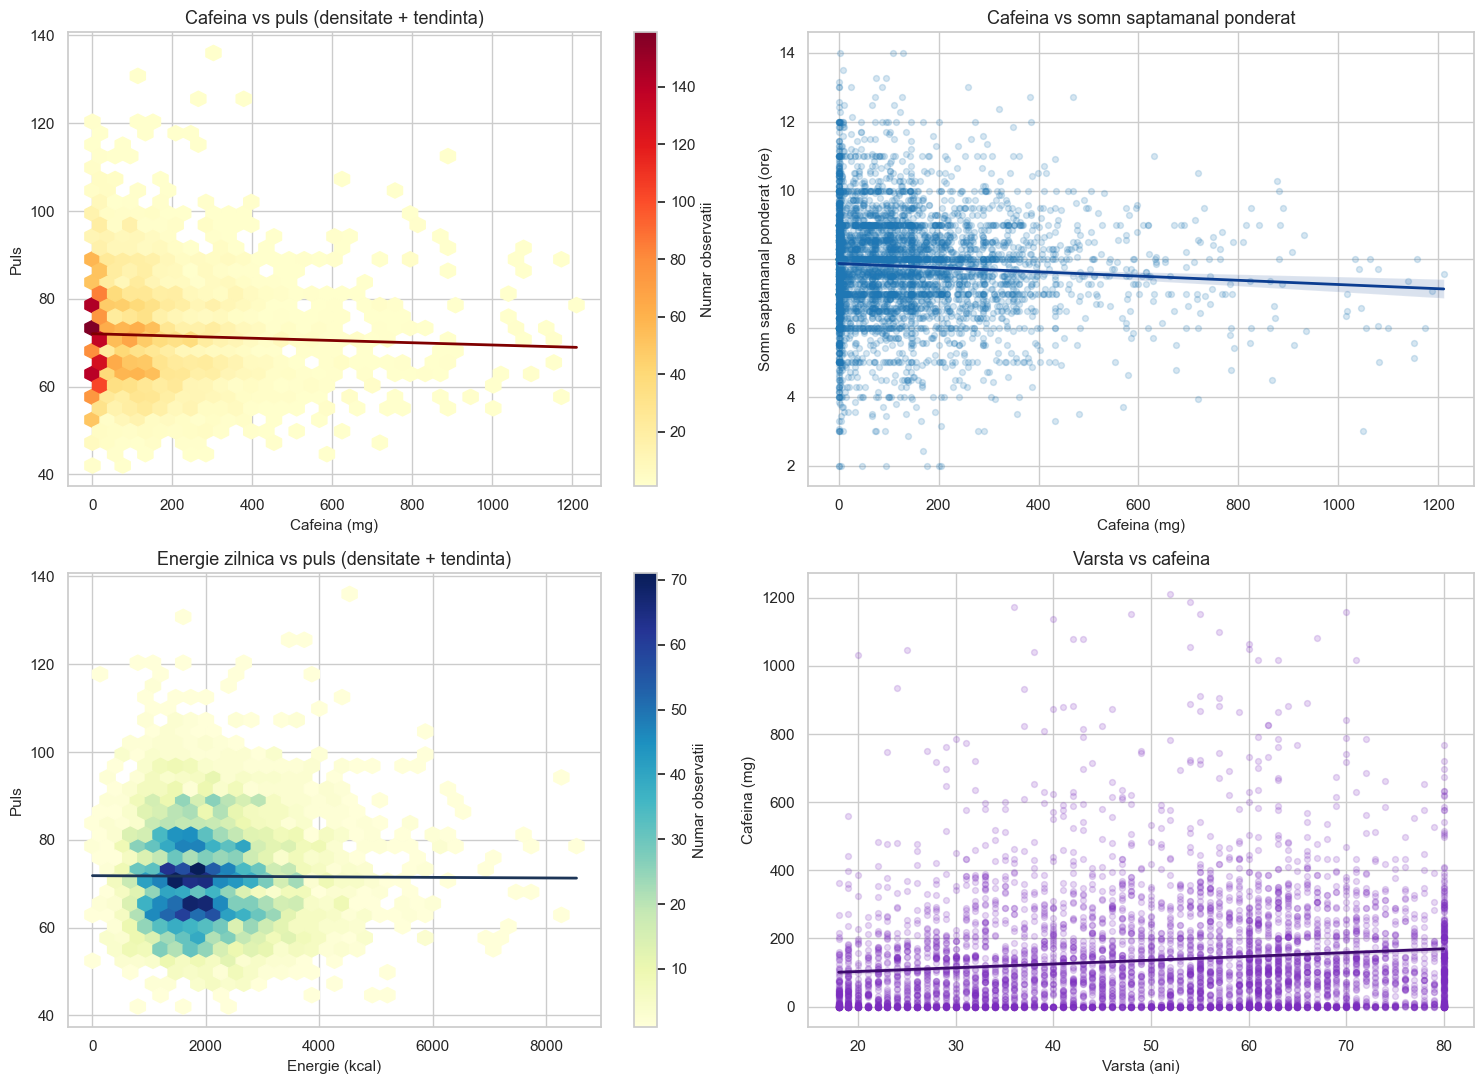

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

scatter_df = analysis_df[["caffeine_mg", "pulse", "avg_sleep_hours", "energy_kcal", "age"]].dropna()

ax = axes[0, 0]
hb1 = ax.hexbin(
    scatter_df["caffeine_mg"],
    scatter_df["pulse"],
    gridsize=32,
    cmap="YlOrRd",
    mincnt=1,
)
trend_coef = np.polyfit(scatter_df["caffeine_mg"], scatter_df["pulse"], 1)
x_line = np.linspace(scatter_df["caffeine_mg"].min(), scatter_df["caffeine_mg"].max(), 200)
ax.plot(x_line, trend_coef[0] * x_line + trend_coef[1], color="#7f0000", linewidth=2)
ax.set_title("Cafeina vs puls (densitate + tendinta)")
ax.set_xlabel("Cafeina (mg)")
ax.set_ylabel("Puls")
plt.colorbar(hb1, ax=ax, label="Numar observatii")

ax = axes[0, 1]
sns.regplot(
    data=scatter_df,
    x="caffeine_mg",
    y="avg_sleep_hours",
    scatter_kws={"alpha": 0.18, "s": 18, "color": "#1f77b4"},
    line_kws={"color": "#0b3d91", "linewidth": 2},
    ax=ax,
)
ax.set_title("Cafeina vs somn saptamanal ponderat")
ax.set_xlabel("Cafeina (mg)")
ax.set_ylabel("Somn saptamanal ponderat (ore)")

ax = axes[1, 0]
hb2 = ax.hexbin(
    scatter_df["energy_kcal"],
    scatter_df["pulse"],
    gridsize=32,
    cmap="YlGnBu",
    mincnt=1,
)
trend_coef = np.polyfit(scatter_df["energy_kcal"], scatter_df["pulse"], 1)
x_line = np.linspace(scatter_df["energy_kcal"].min(), scatter_df["energy_kcal"].max(), 200)
ax.plot(x_line, trend_coef[0] * x_line + trend_coef[1], color="#1d3557", linewidth=2)
ax.set_title("Energie zilnica vs puls (densitate + tendinta)")
ax.set_xlabel("Energie (kcal)")
ax.set_ylabel("Puls")
plt.colorbar(hb2, ax=ax, label="Numar observatii")

ax = axes[1, 1]
sns.regplot(
    data=scatter_df,
    x="age",
    y="caffeine_mg",
    scatter_kws={"alpha": 0.18, "s": 18, "color": "#7b2cbf"},
    line_kws={"color": "#3c096c", "linewidth": 2},
    ax=ax,
)
ax.set_title("Varsta vs cafeina")
ax.set_xlabel("Varsta (ani)")
ax.set_ylabel("Cafeina (mg)")

plt.tight_layout()
plt.show()


### Interpretare dupa graficele de densitate si tendinta

- Pentru relatiile cu multe puncte, reprezentarile de tip hexbin ajuta la identificarea zonelor cu densitate mare, fara sa supraincarce figura.
- Liniile de trend sunt folosite doar ca ghid vizual pentru tendinta generala, nu ca dovada de cauzalitate.
- Relatiile dintre cafeina, somn si puls par in continuare slabe, ceea ce este in acord cu coeficientii de corelatie calculati ulterior.


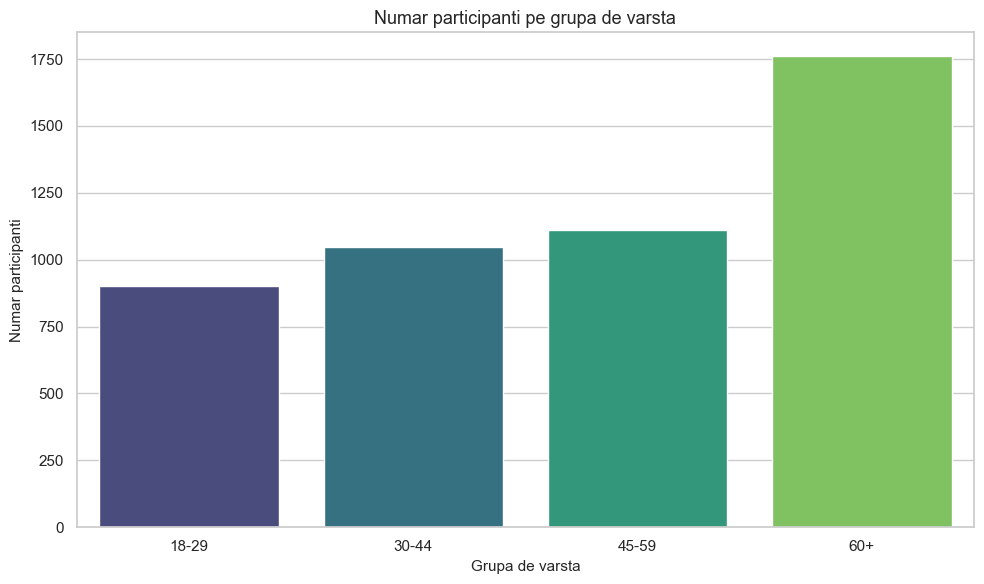

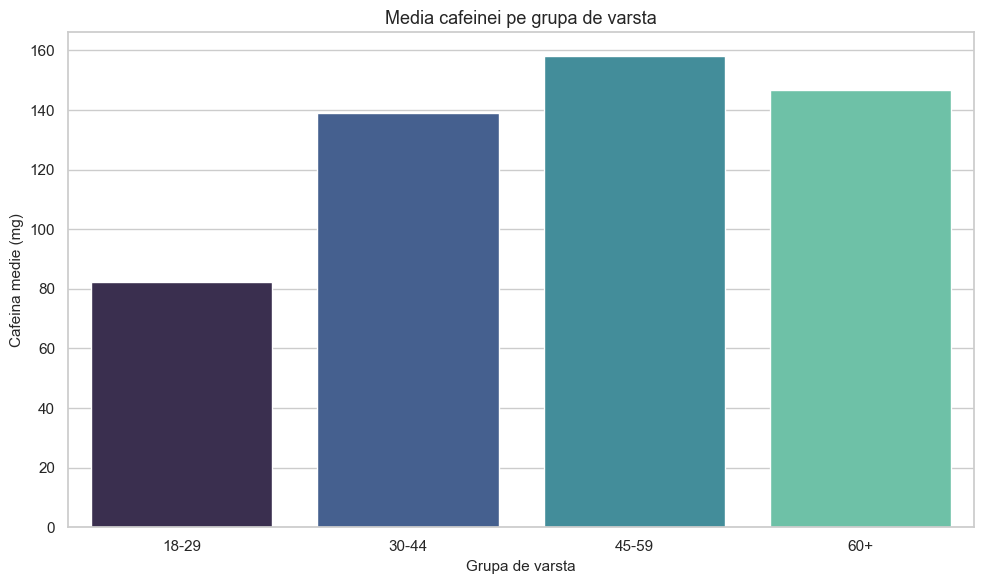

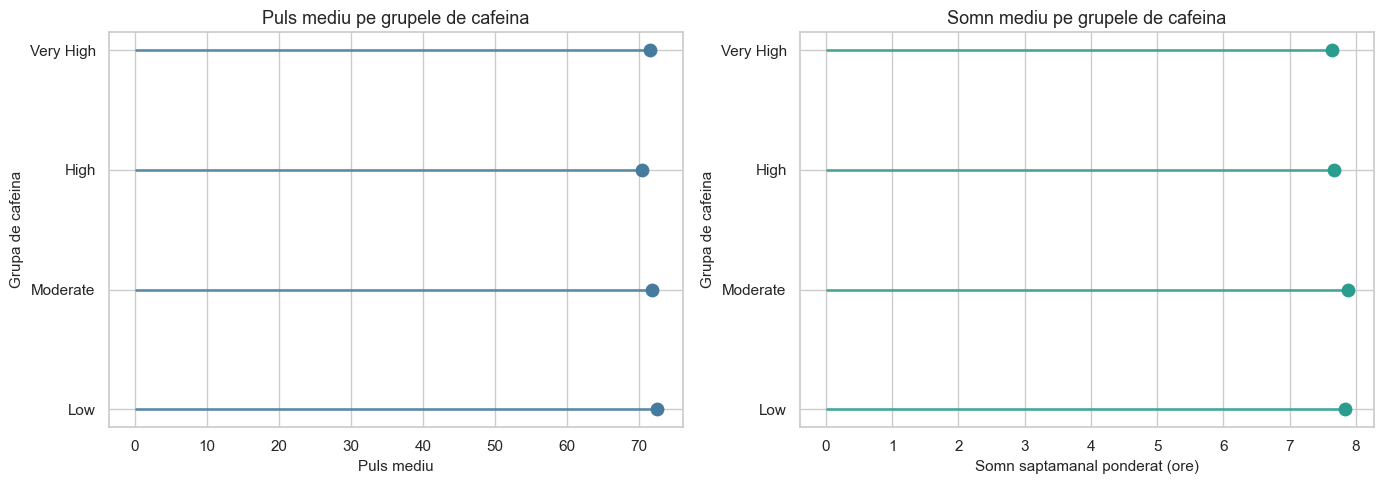

In [22]:
age_group_counts = (
    analysis_df["age_group"]
    .value_counts()
    .sort_index()
    .rename_axis("age_group")
    .reset_index(name="participants")
)

mean_caffeine_by_age = (
    analysis_df.groupby("age_group", observed=False)["caffeine_mg"]
    .mean()
    .reset_index()
)

mean_pulse_by_caffeine = (
    analysis_df.groupby("caffeine_group", observed=False)["pulse"]
    .mean()
    .reset_index()
)

mean_sleep_by_caffeine = (
    analysis_df.groupby("caffeine_group", observed=False)["avg_sleep_hours"]
    .mean()
    .reset_index()
)

ordered_barplot(
    age_group_counts,
    x="age_group",
    y="participants",
    title="Numar participanti pe grupa de varsta",
    xlabel="Grupa de varsta",
    ylabel="Numar participanti",
    palette="viridis"
)

ordered_barplot(
    mean_caffeine_by_age,
    x="age_group",
    y="caffeine_mg",
    title="Media cafeinei pe grupa de varsta",
    xlabel="Grupa de varsta",
    ylabel="Cafeina medie (mg)",
    palette="mako"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lollipop_plot(
    axes[0],
    mean_pulse_by_caffeine,
    category_col="caffeine_group",
    value_col="pulse",
    title="Puls mediu pe grupele de cafeina",
    xlabel="Puls mediu",
    ylabel="Grupa de cafeina",
    color="#457b9d",
)

lollipop_plot(
    axes[1],
    mean_sleep_by_caffeine,
    category_col="caffeine_group",
    value_col="avg_sleep_hours",
    title="Somn mediu pe grupele de cafeina",
    xlabel="Somn saptamanal ponderat (ore)",
    ylabel="Grupa de cafeina",
    color="#2a9d8f",
)

plt.tight_layout()
plt.show()


### Interpretare dupa mediile pe grupuri

- Graficele de tip lollipop pastreaza comparatia numerica a mediilor, dar fac mai usor de urmarit diferentele mici dintre grupele de cafeina.
- Aceste diferente exista, insa nu sunt suficient de mari pentru a sustine singure concluzii puternice despre efecte fiziologice.
- Bar chart-urile clasice au fost pastrate acolo unde ele raman cea mai potrivita alegere pentru sumarizari simple.


Cum se citeste heatmap-ul de corelatie:
- valori aproape de 1: relatie directa, ambele variabile tind sa creasca impreuna
- valori aproape de -1: relatie inversa, cand una creste cealalta tinde sa scada
- valori aproape de 0: relatie liniara slaba sau absenta


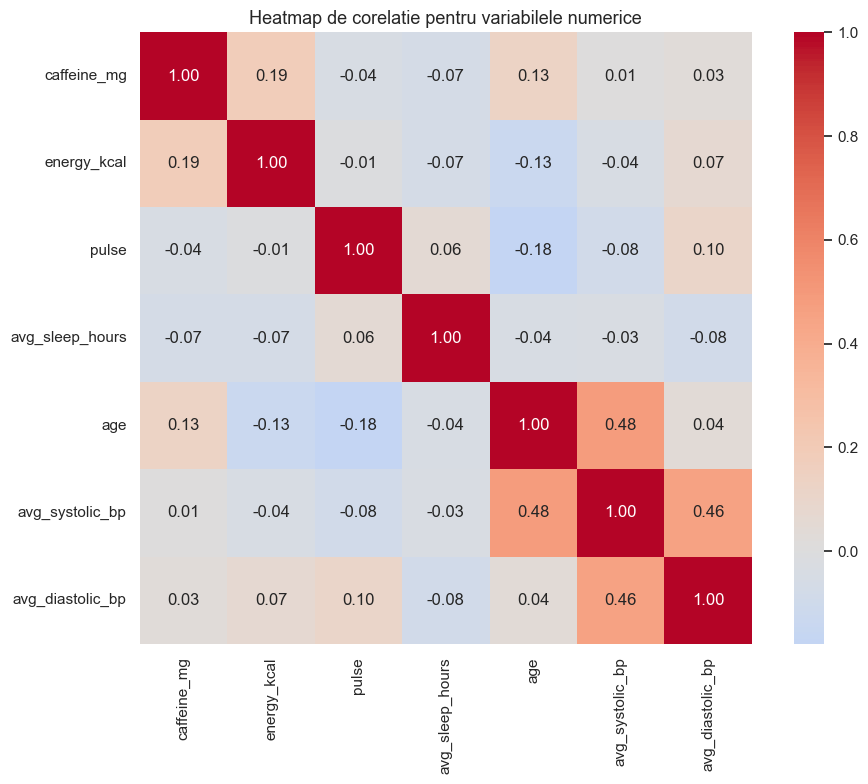

,caffeine_mg,energy_kcal,pulse,avg_sleep_hours,age,avg_systolic_bp,avg_diastolic_bp
caffeine_mg,1.00,0.19,-0.04,-0.07,0.12,0.01,0.03
energy_kcal,0.19,1.00,-0.01,-0.07,-0.13,-0.04,0.07
pulse,-0.04,-0.01,1.00,0.06,-0.18,-0.08,0.10
avg_sleep_hours,-0.07,-0.07,0.06,1.00,-0.04,-0.04,-0.08
age,0.12,-0.13,-0.18,-0.04,1.00,0.48,0.04
avg_systolic_bp,0.01,-0.04,-0.08,-0.04,0.48,1.00,0.46
avg_diastolic_bp,0.03,0.07,0.10,-0.08,0.04,0.46,1.00


,feature_1,feature_2,correlation,tip_relatie
18,age,avg_systolic_bp,0.48,directa
20,avg_systolic_bp,avg_diastolic_bp,0.46,directa
0,caffeine_mg,energy_kcal,0.19,directa
12,pulse,age,-0.18,inversa
8,energy_kcal,age,-0.13,inversa
3,caffeine_mg,age,0.12,directa
14,pulse,avg_diastolic_bp,0.10,directa
13,pulse,avg_systolic_bp,-0.08,inversa
17,avg_sleep_hours,avg_diastolic_bp,-0.08,inversa
10,energy_kcal,avg_diastolic_bp,0.07,directa


In [23]:
numeric_columns = [
    "caffeine_mg",
    "energy_kcal",
    "pulse",
    "avg_sleep_hours",
    "age",
    "avg_systolic_bp",
    "avg_diastolic_bp",
]

correlation_matrix = analysis_df[numeric_columns].corr(numeric_only=True)

print("Cum se citeste heatmap-ul de corelatie:")
print("- valori aproape de 1: relatie directa, ambele variabile tind sa creasca impreuna")
print("- valori aproape de -1: relatie inversa, cand una creste cealalta tinde sa scada")
print("- valori aproape de 0: relatie liniara slaba sau absenta")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, center=0)
plt.title("Heatmap de corelatie pentru variabilele numerice")
plt.tight_layout()
plt.show()

display(correlation_matrix.round(3))

upper_triangle_mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
upper_triangle = correlation_matrix.where(upper_triangle_mask)

top_correlations = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)
top_correlations["tip_relatie"] = np.where(top_correlations["correlation"] >= 0, "directa", "inversa")
top_correlations["abs_correlation"] = top_correlations["correlation"].abs()
top_correlations["correlation"] = top_correlations["correlation"].round(3)
top_correlations = top_correlations.sort_values("abs_correlation", ascending=False)

display(top_correlations[["feature_1", "feature_2", "correlation", "tip_relatie"]].head(10))


In [24]:
sleep_by_caffeine_group = (
    analysis_df.groupby("caffeine_group", observed=False)["avg_sleep_hours"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

pulse_by_caffeine_group = (
    analysis_df.groupby("caffeine_group", observed=False)["pulse"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

caffeine_by_age_group = (
    analysis_df.groupby("age_group", observed=False)["caffeine_mg"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

caffeine_by_gender = (
    analysis_df.groupby("gender", dropna=False)["caffeine_mg"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("Somn mediu pe grupele de cafeina:")
display(sleep_by_caffeine_group)

print("Puls mediu pe grupele de cafeina:")
display(pulse_by_caffeine_group)

print("Consum de cafeina pe grupele de varsta:")
display(caffeine_by_age_group)

print("Consum de cafeina pe sexe:")
display(caffeine_by_gender)


Somn mediu pe grupele de cafeina:


,count,mean,median,std
caffeine_group,,,,
Low,1792,7.84,7.93,1.64
Moderate,1447,7.88,8.00,1.49
High,967,7.68,7.79,1.38
Very High,591,7.64,7.64,1.43


Puls mediu pe grupele de cafeina:


,count,mean,median,std
caffeine_group,,,,
Low,1810,72.47,72.00,11.84
Moderate,1450,71.77,70.00,11.33
High,972,70.41,70.00,11.25
Very High,592,71.50,70.00,11.77


Consum de cafeina pe grupele de varsta:


,count,mean,median,std
age_group,,,,
18-29,903,82.23,37.00,120.59
30-44,1049,138.97,93.00,168.09
45-59,1110,158.18,112.00,175.18
60+,1762,146.58,104.00,161.00


Consum de cafeina pe sexe:


,count,mean,median,std
gender,,,,
Female,2474,119.17,78.00,142.55
Male,2350,152.79,104.00,177.67


In [25]:
pearson_results = pd.DataFrame([
    {
        "analiza": "Cafeina vs puls",
        "pearson_r": analysis_df[["caffeine_mg", "pulse"]].dropna().corr().iloc[0, 1]
    },
    {
        "analiza": "Cafeina vs somn saptamanal ponderat",
        "pearson_r": analysis_df[["caffeine_mg", "avg_sleep_hours"]].dropna().corr().iloc[0, 1]
    },
]).round(3)

low_vs_very_high = pd.DataFrame([
    {
        "analiza": "Diferenta puls mediu (Very High - Low)",
        "difference": (
            analysis_df.loc[analysis_df["caffeine_group"] == "Very High", "pulse"].mean()
            - analysis_df.loc[analysis_df["caffeine_group"] == "Low", "pulse"].mean()
        )
    },
    {
        "analiza": "Diferenta somn saptamanal ponderat (Very High - Low)",
        "difference": (
            analysis_df.loc[analysis_df["caffeine_group"] == "Very High", "avg_sleep_hours"].mean()
            - analysis_df.loc[analysis_df["caffeine_group"] == "Low", "avg_sleep_hours"].mean()
        )
    },
]).round(3)

display(pearson_results)
display(low_vs_very_high)


,analiza,pearson_r
0,Cafeina vs puls,-0.04
1,Cafeina vs somn saptamanal ponderat,-0.07


,analiza,difference
0,Diferenta puls mediu (Very High - Low),-0.97
1,Diferenta somn saptamanal ponderat (Very High ...,-0.21


In [26]:
def _strength_label(value):
    abs_value = abs(value)
    if abs_value < 0.10:
        return "foarte slaba"
    if abs_value < 0.30:
        return "slaba"
    if abs_value < 0.50:
        return "moderata"
    return "puternica"

pulse_corr = float(pearson_results.loc[pearson_results["analiza"] == "Cafeina vs puls", "pearson_r"].iloc[0])
sleep_corr = float(pearson_results.loc[pearson_results["analiza"] == "Cafeina vs somn saptamanal ponderat", "pearson_r"].iloc[0])
very_high_pulse_diff = float(low_vs_very_high.loc[low_vs_very_high["analiza"] == "Diferenta puls mediu (Very High - Low)", "difference"].iloc[0])
very_high_sleep_diff = float(low_vs_very_high.loc[low_vs_very_high["analiza"] == "Diferenta somn saptamanal ponderat (Very High - Low)", "difference"].iloc[0])

eda_md = f"""
### Interpretare scurta dupa EDA

- Relatia dintre cafeina si puls pare **{_strength_label(pulse_corr)}** in termeni liniari, cu Pearson **{pulse_corr:.3f}**.
- Relatia dintre cafeina si somnul saptamanal ponderat pare **{_strength_label(sleep_corr)}**, cu Pearson **{sleep_corr:.3f}**.
- Diferenta medie de puls dintre grupele `Very High` si `Low` este de aproximativ **{very_high_pulse_diff:.2f}** batai/minut.
- Diferenta medie de somn saptamanal ponderat dintre grupele `Very High` si `Low` este de aproximativ **{very_high_sleep_diff:.2f}** ore.
- Aceste rezultate sustin doar partial ipotezele initiale si trebuie citite ca asocieri, nu ca efecte cauzale.
"""

display(Markdown(eda_md))



### Interpretare scurta dupa EDA

- Relatia dintre cafeina si puls pare **foarte slaba** in termeni liniari, cu Pearson **-0.037**.
- Relatia dintre cafeina si somnul saptamanal ponderat pare **foarte slaba**, cu Pearson **-0.065**.
- Diferenta medie de puls dintre grupele `Very High` si `Low` este de aproximativ **-0.97** batai/minut.
- Diferenta medie de somn saptamanal ponderat dintre grupele `Very High` si `Low` este de aproximativ **-0.21** ore.
- Aceste rezultate sustin doar partial ipotezele initiale si trebuie citite ca asocieri, nu ca efecte cauzale.


### 3.1 Vizualizare-sinteza: profil comparativ al grupurilor de consum de cafeina

Radar chart-ul este folosit doar ca rezumat vizual al profilurilor standardizate pentru grupurile de consum de cafeina. El nu trebuie interpretat ca scor clinic sau ca ierarhie de tip mai bun sau mai rau.

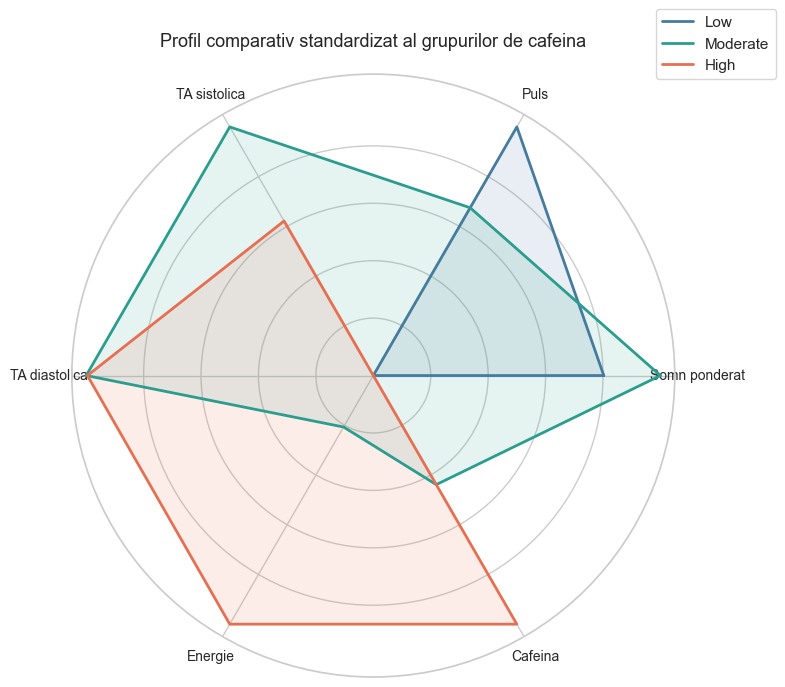

,avg_sleep_hours,pulse,avg_systolic_bp,avg_diastolic_bp,energy_kcal,caffeine_mg
caffeine_group,,,,,,
Low,7.84,72.47,125.08,71.74,"1,970.37",11.17
Moderate,7.88,71.77,127.58,73.30,"2,025.03",100.97
High,7.68,70.41,126.66,73.34,"2,233.59",216.06


In [27]:
radar_features = [
    "avg_sleep_hours",
    "pulse",
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "energy_kcal",
    "caffeine_mg",
]
radar_groups = ["Low", "Moderate", "High"]

radar_base_df = analysis_df[analysis_df["caffeine_group"].isin(radar_groups)][["caffeine_group"] + radar_features].dropna()

radar_scaled_values = StandardScaler().fit_transform(radar_base_df[radar_features])
radar_scaled_df = pd.DataFrame(radar_scaled_values, columns=radar_features, index=radar_base_df.index)
radar_scaled_df["caffeine_group"] = radar_base_df["caffeine_group"].values

radar_profile_z = (
    radar_scaled_df.groupby("caffeine_group", observed=False)[radar_features]
    .mean()
    .loc[radar_groups]
)

radar_profile_plot = radar_profile_z.copy()
for column in radar_profile_plot.columns:
    col_min = radar_profile_plot[column].min()
    col_max = radar_profile_plot[column].max()
    if np.isclose(col_min, col_max):
        radar_profile_plot[column] = 0.5
    else:
        radar_profile_plot[column] = (radar_profile_plot[column] - col_min) / (col_max - col_min)

radar_labels = {
    "avg_sleep_hours": "Somn ponderat",
    "pulse": "Puls",
    "avg_systolic_bp": "TA sistolica",
    "avg_diastolic_bp": "TA diastolica",
    "energy_kcal": "Energie",
    "caffeine_mg": "Cafeina",
}

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

for group in radar_groups:
    values = radar_profile_plot.loc[group].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=group, color=radar_palette[group])
    ax.fill(angles, values, alpha=0.12, color=radar_palette[group])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([radar_labels[col] for col in radar_features], fontsize=10)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels([])
ax.set_title("Profil comparativ standardizat al grupurilor de cafeina", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.18, 1.12))
plt.tight_layout()
plt.show()

display(
    analysis_df[analysis_df["caffeine_group"].isin(radar_groups)]
    .groupby("caffeine_group", observed=False)[radar_features]
    .mean()
    .loc[radar_groups]
    .round(2)
)


### Interpretare dupa radar chart

- Graficul ajuta la compararea simultana a mai multor dimensiuni relevante, nu la formularea unui verdict clinic.
- Diferentele dintre grupuri trebuie citite ca profiluri relative standardizate, nu ca masuratori absolute.
- Radar chart-ul este util pentru prezentare deoarece rezuma intr-o singura figura informatia din mai multe tabele si grafice anterioare.

### 3.2 Observatii finale pentru partea de analiza exploratorie

- In date apar legaturi vizibile, dar in general slabe, intre cafeina, somn si puls.
- Diferentele dintre grupuri exista, dar trebuie interpretate prudent, deoarece lucram cu date observationale.
- Aceasta etapa ne ajuta sa formulam ipoteze plauzibile si sa pregatim baza pentru modelarea din checkpoint-ul urmator.